## Perform logistic regression using parceptron technique

In [176]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [217]:
X,y = make_classification(n_samples=100,n_features=2,n_informative= 1, n_redundant=0,n_classes=2 
                   ,n_clusters_per_class=1 ,random_state=41, hypercube=False,class_sep=30)

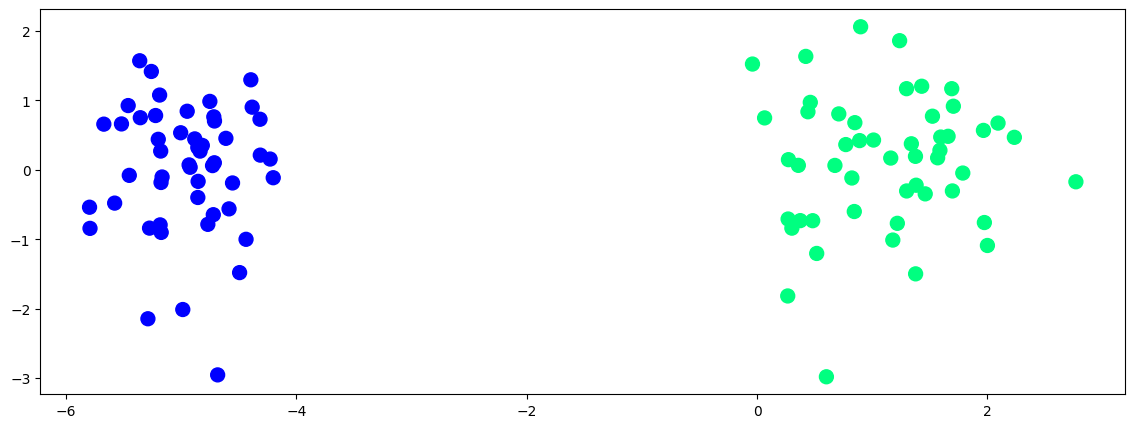

In [178]:
plt.figure(figsize=(14,5))
plt.scatter(X[:,0],X[:,1], c=y ,cmap='winter',s=100)

In [179]:
X

array([[ 0.82321545, -0.11697552],
       [ 0.37514771, -0.73115232],
       [ 0.26947761, -0.7081059 ],
       [-4.98744874, -2.01199214],
       [ 0.4231285 ,  1.63493163],
       [-4.2289949 ,  0.15599044],
       [-5.18865382,  1.07782053],
       [ 0.7096287 ,  0.80626713],
       [ 0.06531501,  0.74859527],
       [-5.3563263 ,  0.75152794],
       [-5.17487315, -0.90114581],
       [-5.17644221, -0.1815243 ],
       [ 0.60202649, -2.98092432],
       [ 1.42960231,  1.20500136],
       [-5.22359581,  0.78302407],
       [ 1.01127528,  0.42968688],
       [ 0.48288133, -0.73229726],
       [-5.27614308, -0.83930476],
       [ 0.44163889,  0.83727062],
       [-5.167179  , -0.10255323],
       [-5.67316396,  0.65867001],
       [-5.4617787 ,  0.92649819],
       [-4.71348919,  0.10216193],
       [ 2.2344006 ,  0.46886454],
       [-4.61308761,  0.45432938],
       [ 1.2379403 ,  1.8613386 ],
       [-5.18419324, -0.79255991],
       [-4.43807529, -1.0004391 ],
       [-5.79725951,

In [180]:

def perceptron(X,y): 
  X = np.insert(X,0,1,axis=1)
  weight = np.ones(X.shape[1])

  lr = 0.01
  epoches = 1000

  for i in range(epoches):
    j = np.random.randint(0,100)
    y_hat = step(np.dot(X[j],weight))
    weight = weight + lr*(y[j]- y_hat)* X[j]

  return weight[0],weight[1:]    
    

In [181]:
def step(z):
    return 1 if z>0 else 0



In [182]:
intersept,coff = perceptron(X,y)

In [183]:
print(intersept)
print(coff)

1.11
[1.04607697 0.74195542]


In [184]:
intersept

np.float64(1.11)

In [185]:
m = -(coff[0]/coff[1])
b = -(intersept/coff[1])
print(m,b)

-1.4098919415906401 -1.4960467560969444


In [186]:
x_input = X
y_input = m * x_input + b

(-3.0, 2.0)

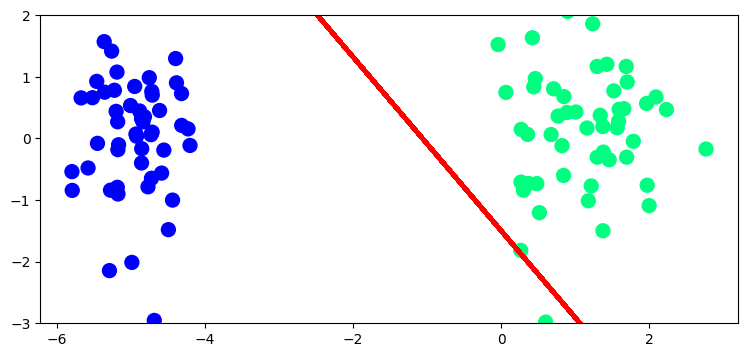

In [187]:
plt.figure(figsize=(9,4))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

### Now we discussed over model performance poor than logistic regression model 

(-3.0, 2.0)

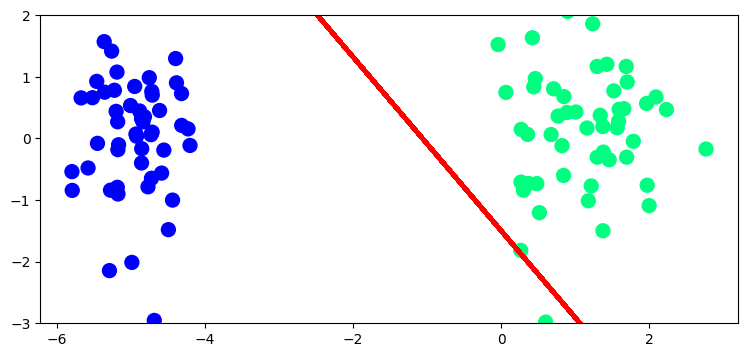

In [188]:
# 2.1
plt.figure(figsize=(9,4))
plt.plot(x_input,y_input,color='red',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)

1. over model are fit a best line they classified points or distangish both group 

2. in which model select a random point in data set and predict it positive or nagetive if line below the negative point means it classified negative point as positive . so according over formula or equation we multiply by weight (ki esi value se jo point ko negetive group me dalde means) line move positive 
this process do in epoches (loop)

3.problem see in image 2.1 image inwhich line is very close to positive green point beacse over model is do only classified point and disrtanges than not do some effort to fix best line it should be vertical line thay give best result on test data this problem with over perceptron model

4.in this situcation logistic regression make a vertical line they create eaqul margin do some effort 

#### solution below we improve over perceptron model

In [212]:
# first we used sklearn logistic regression model built and drow line to check which is betteer performance

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [213]:
m = -(lr.coef_[0][0] / lr.coef_[0][1])
m
b = -(lr.intercept_ / lr.coef_[0][1])
b

array([-297.9404898])

In [214]:
x_inp = X
x_inp

y_inp = m* x_input + b


### conclusion 

1. i train my dataset on sklearn built in model logistic regression and they excellently perform well as campare to my scratch model 

2. lets see in bellow figure black line is sklearn built in model and red line is my model you see black line is equaly separete distance from both positive and negetive points like student cgpa and iq and output 1 and 0 means beloow line left side point means placment nhi hua and right side placment ho gya 

3. becuse over line touch with positive line so it fail on testing or production becuse they not eaqualy seprated  



C:\Users\dilip\AppData\Local\Temp\ipykernel_8780\3472831830.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[:,0],X[:,1],cmap='winter',s=100)


(-3.0, 2.0)

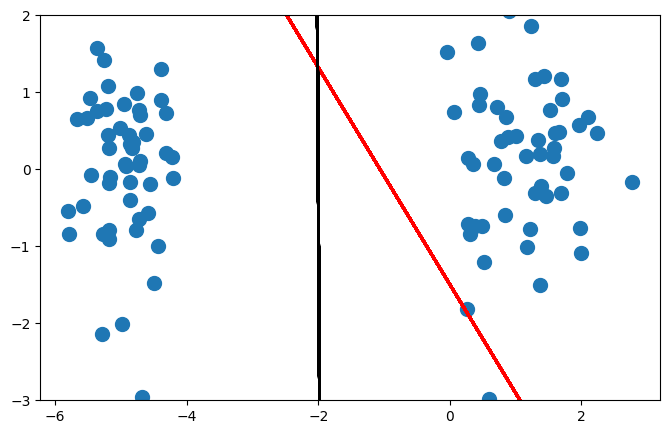

In [215]:
plt.figure(figsize=(8,5))
plt.plot(x_input,y_input,color='red',linewidth=2)
plt.plot(x_inp,y_inp,color='black',linewidth=2)
plt.scatter(X[:,0],X[:,1],cmap='winter',s=100)
plt.ylim(-3,2)

## solution : Now we used sigmoid funtion inplace of step funtion becuse step function give only 0 and 1 value  but sigmoid provide a probablity besd and ans see

sigmoid funtion so big value ko  0 and 1 ki range me le ata he  means agar value line se dur he like right corner me last value they give high value like 0.8 and pass vale point jo line ke pass he unhe 0.6 probebility so hum 

solution algo : pehle agar model predict karta he y_head one or actual value y = 1 hoti he line me kuch nhi hota becuse formula is
 weight_new = weight_old + lr*(y-y_head)*xi so ager wieght_new = weight_old + lr*(1-1)*x  so weight_new = weight_old line no change 

 changes do when predicted either negative but actual positive to hum line ko niche layenge negetive side or predicted 1 but actual is negetive so hum line upper ki taraf move hogi wegiht badane par in line jise line positive side or negetive side chipak ke rehti he jisse chance he testing me phel 

 sigmoid funtion ki help se hum age point positive and predicted positive he agar point line ke pass he to ye jor se push karega means pehle kuch nhi ho rha tha par ab changes hoga jisse dono traf se line ko pull or push karne se wah dono data ke center me ache se fit hogi like sklearn bulit in model 
 black line so lets start we do some changes over existing code 


 ### solution using sigmoid funtion  


[1. 1. 1.]


In [220]:
  
def parceptron(X,y): 
  X = np.insert(X,0,1,axis=1)
  weight = np.ones(X.shape[1])

  lr = 0.01
  epoches = 1000

  for i in range(epoches):
    j = np.random.randint(0,100)
    y_hat = sigmoid(np.dot(X[j],weight))
    weight = weight + lr*(y[j] - y_hat)*X[j]

  return weight[0],weight[1:]    
 


    

In [221]:
def sigmoid(z):

    return 1 / (1 + np.exp(-z))

In [236]:
parceptron(X,y)

(np.float64(1.4290083990038394), array([1.52611702, 0.6888789 ]))

In [237]:
intersept_,coef_ = parceptron(X,y)

In [238]:
intersept_

np.float64(1.4608214378728421)

In [239]:
coef_

array([1.52998072, 0.59863017])

In [240]:
# now we calculate m and b value using this eqution y = Ax + By + c = 0  m = -A/B , b  -c/B  A = coef_[0] and B = coef_[1] , C = intersept_

m = -(coef_[0]/coef_[1])

b = -(intersept_ / coef_[1])

print(m,b)



-2.5558029036354664 -2.4402736789938744


## we are creating a graph and check over model performance now by applying sigmoid fun



In [241]:
x_inputs = X

y_inputs = m * X + b 

### pink line is now over sigmoid funtion applying in over fun to do some lavel better than over red line over previeus model but after that we dont equal to built in sklearn model so next again i find some optimization

(-3.0, 2.0)

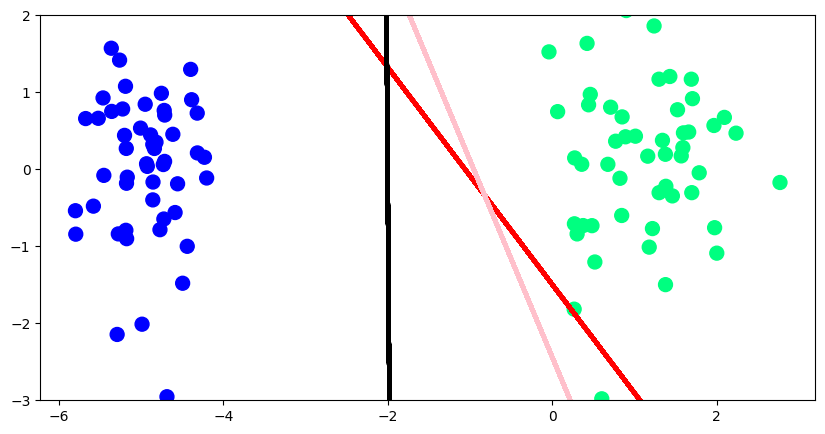

In [242]:
plt.figure(figsize=(10,5))
plt.plot(x_input,y_input, color='red', linewidth=3)
plt.plot(x_inp,y_inp,color='black',linewidth=3)
plt.plot(x_inputs,y_inputs,color='pink',linewidth=3)
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.ylim(-3,2)